In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


In [14]:
# load dataset heads:
dataset_iteration_30 = pd.read_csv("datasets/apache_iteration_30_features.csv")
dataset_iteration_30.head(1)

,boardid,sprintid,name,vel_diff,planday,no_issue_starttime,vel_starttime,no_issue_added,vel_added,no_issue_removed,...,type_freq_Story,priority_freq_Trivial,type_freq_Documentation,type_freq_Wish,priority_freq_Blocker,type_freq_Sub-task,type_freq_Technical task,type_freq_New Feature,type_freq_Test,type_freq_Umbrella
0,1,8,Q2'14 Sprint 1,0,9,0,0,2,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from custom_kfold import CustomKFold
from sdee_statistics import calculate_nmae
from train_dataset import get_X_y, train_model_cv

X, y = get_X_y(dataset_iteration_30)

n_folds = 10
kf = CustomKFold(n_splits=n_folds, shuffle=False)

# train model
model = RandomForestRegressor(n_estimators=500, max_depth=7)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

# nmae = train_model_cv(X, y, model, kf)

# Initialize and train the model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

nmae = calculate_nmae(y_test, y_pred)
print(f"{model.__class__.__name__} nmae: {nmae}")

RandomForestRegressor nmae: 0.3693706760350896


### Feature importances

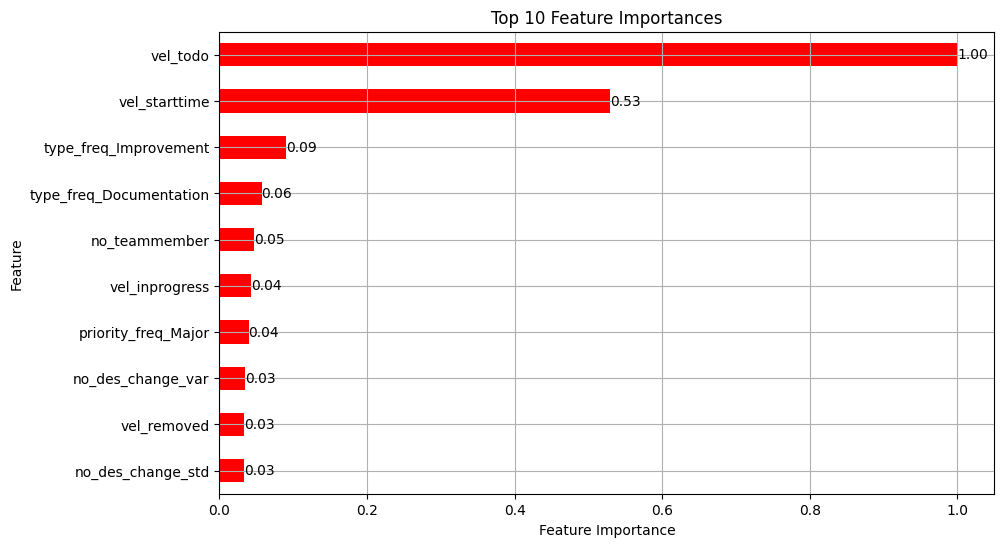

In [4]:
from sklearn.preprocessing import MinMaxScaler

# get the feature ranking of the rf model:
myClassifiers = pd.Series(model.feature_importances_, index=X.columns)

# Normalize feature importances
scaler = MinMaxScaler()
myClassifiers_normalized = scaler.fit_transform(myClassifiers.values.reshape(-1, 1)).flatten()
myClassifiers_normalized = pd.Series(myClassifiers_normalized, index=myClassifiers.index)

# Sort the Series by importance in descending order
myClassifiers_normalized = myClassifiers_normalized.sort_values(ascending=False)

# Plot only the top 10 most relevant features
top_n = 10
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances")
myClassifiers_normalized[:top_n].plot(kind='barh', color='r')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.grid()
plt.gca().invert_yaxis()  # Invert y-axis to have the most relevant feature at the top
# Annotate each bar with its value
for i, value in enumerate(myClassifiers_normalized[:top_n]):
    plt.text(value, i, f'{value:.2f}', ha='left', va='center')
plt.show()

### Try if reduced Features subset reduces NMAE

In [23]:
from sklearn.feature_selection import (
    SelectPercentile,
    f_regression,
    mutual_info_regression,
)
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline


X, y = get_X_y(dataset_iteration_30)
kf = CustomKFold(n_splits=10, shuffle=False)
model = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)

percentiles = [20, 40, 60, 100]

# Select features based on the specified percentages
for percentile in percentiles:
    print(f"Training model for {percentile}% of the features:")
    # Define the pipeline
    pipeline = Pipeline(
        [
            # try f_regression and mutual_info_regression
            (
                "feature_selection",
                SelectPercentile(percentile=percentile, score_func=mutual_info_regression),
            ),
            ("regression", model),
        ]
    )

    nmae_values = []
    #nmae_scorer = make_scorer(calculate_nmae, greater_is_better=False)
    #nmae_values = cross_val_score(pipeline, X, y, cv=kf, scoring=nmae_scorer)
    for train_index, test_index in kf.split(X):
       X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[test_index]
       y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[test_index]

       # Fit the pipeline on the training data
       pipeline.fit(X_train_fold, y_train_fold)
       print(f"Features selected: {X.columns[pipeline.named_steps['feature_selection'].get_support()]}")

       # Predict on the validation data
       y_pred_fold = pipeline.predict(X_val_fold)

       # Calculate NMAE for this fold
       nmae = calculate_nmae(y_val_fold, y_pred_fold)
       nmae_values.append(nmae)
    print(f"avg nmae: {sum(nmae_values) / len(nmae_values)}")
    print("=" * 40)

Training model for 20% of the features:
Features selected: Index(['no_issue_starttime', 'vel_starttime', 'no_issuetodo', 'vel_todo',
       'no_teammember', 'no_issues', 'priority_freq_Major', 'no_comment_std',
       'no_comment_var', 'no_fixversion_max', 'no_fixversion_std',
       'no_fixversion_var', 'no_issuelink_std', 'no_des_change_max',
       'no_des_change_mean', 'no_des_change_std', 'no_des_change_var',
       'no_des_change_range', 'gunning_fog_freq_easy',
       'gunning_fog_freq_hard'],
      dtype='object')
Features selected: Index(['no_issue_starttime', 'vel_starttime', 'no_issuetodo', 'vel_todo',
       'no_teammember', 'no_issues', 'priority_freq_Major', 'no_comment_std',
       'no_fixversion_std', 'no_fixversion_range', 'no_issuelink_mean',
       'no_issuelink_std', 'no_issuelink_range', 'no_des_change_max',
       'no_des_change_mean', 'no_des_change_std', 'no_des_change_var',
       'no_des_change_range', 'gunning_fog_freq_easy',
       'gunning_fog_freq_hard'],
